In [333]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

## Aditional function


In [334]:
def show_bgr_pair(
    original,
    corrected,
    original_title="Original",
    corrected_title="Corrected",
    max_width=1200
):
    """
    Display original and corrected BGR images in one figure.
    """

    def resize_for_display(img):
        height, width = img.shape[:2]
        scale = min(1.0, max_width / width)

        if scale < 1.0:
            img = cv2.resize(
                img,
                (
                    int(width * scale),
                    int(height * scale)
                ),
                interpolation=cv2.INTER_AREA
            )

        return img

    original_display = resize_for_display(original)
    corrected_display = resize_for_display(corrected)

    original_rgb = cv2.cvtColor(
        original_display,
        cv2.COLOR_BGR2RGB
    )

    corrected_rgb = cv2.cvtColor(
        corrected_display,
        cv2.COLOR_BGR2RGB
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 10)
    )

    axes[0].imshow(original_rgb)
    axes[0].set_title(original_title)
    axes[0].axis("off")

    axes[1].imshow(corrected_rgb)
    axes[1].set_title(corrected_title)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## Settings

In [335]:
# --------------------------------------------------
# File paths
# --------------------------------------------------
input_path = Path.cwd().parent / "full_view" / "Balbc_10x_2k.jpg"
output_path = Path.cwd().parent / "full_view" / "Balbc_10x_2k_corrected.png"

In [ ]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
background_blur = 901
correction_strength = 1
clahe_clip_limit = 2.0
clahe_grid_size = (32, 32)


## Working_body

In [386]:
# --------------------------------------------------
# Load image using Pillow
# --------------------------------------------------
with Image.open(input_path) as pil_image:
    rgb_image = pil_image.convert("RGB")

# Convert Pillow RGB image to OpenCV BGR format
rgb = np.array(rgb_image)
bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

print("Image loaded:", bgr.shape)

Image loaded: (6890, 2835, 3)


In [387]:
# --------------------------------------------------
# Create a tissue mask
# --------------------------------------------------
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

saturation = hsv[:, :, 1]
value = hsv[:, :, 2]

# Tissue is usually more saturated than the gray checkerboard background
tissue_mask = ((saturation > 18) & (value < 250)).astype(np.uint8) * 255

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (15, 15)
)

tissue_mask = cv2.morphologyEx(
    tissue_mask,
    cv2.MORPH_CLOSE,
    kernel
)

tissue_mask = cv2.morphologyEx(
    tissue_mask,
    cv2.MORPH_OPEN,
    kernel
)

tissue_mask = cv2.dilate(
    tissue_mask,
    np.ones((9, 9), np.uint8)
)

In [388]:
# --------------------------------------------------
# Convert to Lab color space
# --------------------------------------------------
lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)

lightness, a_channel, b_channel = cv2.split(lab)

In [389]:
# --------------------------------------------------
# Estimate and correct uneven illumination
# --------------------------------------------------
background = cv2.GaussianBlur(
    lightness,
    (background_blur, background_blur),
    0
)

background = np.maximum(
    background.astype(np.float32),
    1.0
)

lightness_float = lightness.astype(np.float32)

corrected_lightness = (
    lightness_float / background
)

# Use the median tissue brightness as the target level
tissue_pixels = corrected_lightness[tissue_mask > 0]

if tissue_pixels.size > 0:
    target_brightness = np.median(
        lightness.astype(np.float32)[tissue_mask > 0]
    )
else:
    target_brightness = np.median(lightness)

corrected_lightness = corrected_lightness * target_brightness

corrected_lightness = np.clip(
    corrected_lightness,
    0,
    255
).astype(np.uint8)


# Blend corrected and original lightness
corrected_lightness = cv2.addWeighted(
    lightness,
    1.0 - correction_strength,
    corrected_lightness,
    correction_strength,
    0
)


In [ ]:
# -----------------------------
# Improve local contrast with CLAHE
# -----------------------------
clahe = cv2.createCLAHE(
    clipLimit=clahe_clip_limit,
    tileGridSize=clahe_grid_size
)

enhanced_lightness = clahe.apply(corrected_lightness)

In [ ]:

# --------------------------------------------------
# Preserve the original checkerboard background
# --------------------------------------------------
mask_float = tissue_mask.astype(np.float32) / 255.0
mask_float = cv2.GaussianBlur(
    mask_float,
    (21, 21),
    0
)

final_lightness = (
    enhanced_lightness.astype(np.float32) * mask_float
    + lightness.astype(np.float32) * (1.0 - mask_float)
)

final_lightness = np.clip(
    final_lightness,
    0,
    255
).astype(np.uint8)

In [391]:
# --------------------------------------------------
# Reconstruct corrected color image
# --------------------------------------------------
corrected_lab = cv2.merge([
    final_lightness,
    a_channel,
    b_channel
])

corrected_bgr = cv2.cvtColor(
    corrected_lab,
    cv2.COLOR_LAB2BGR
)

corrected_rgb = cv2.cvtColor(
    corrected_bgr,
    cv2.COLOR_BGR2RGB
)

## Output

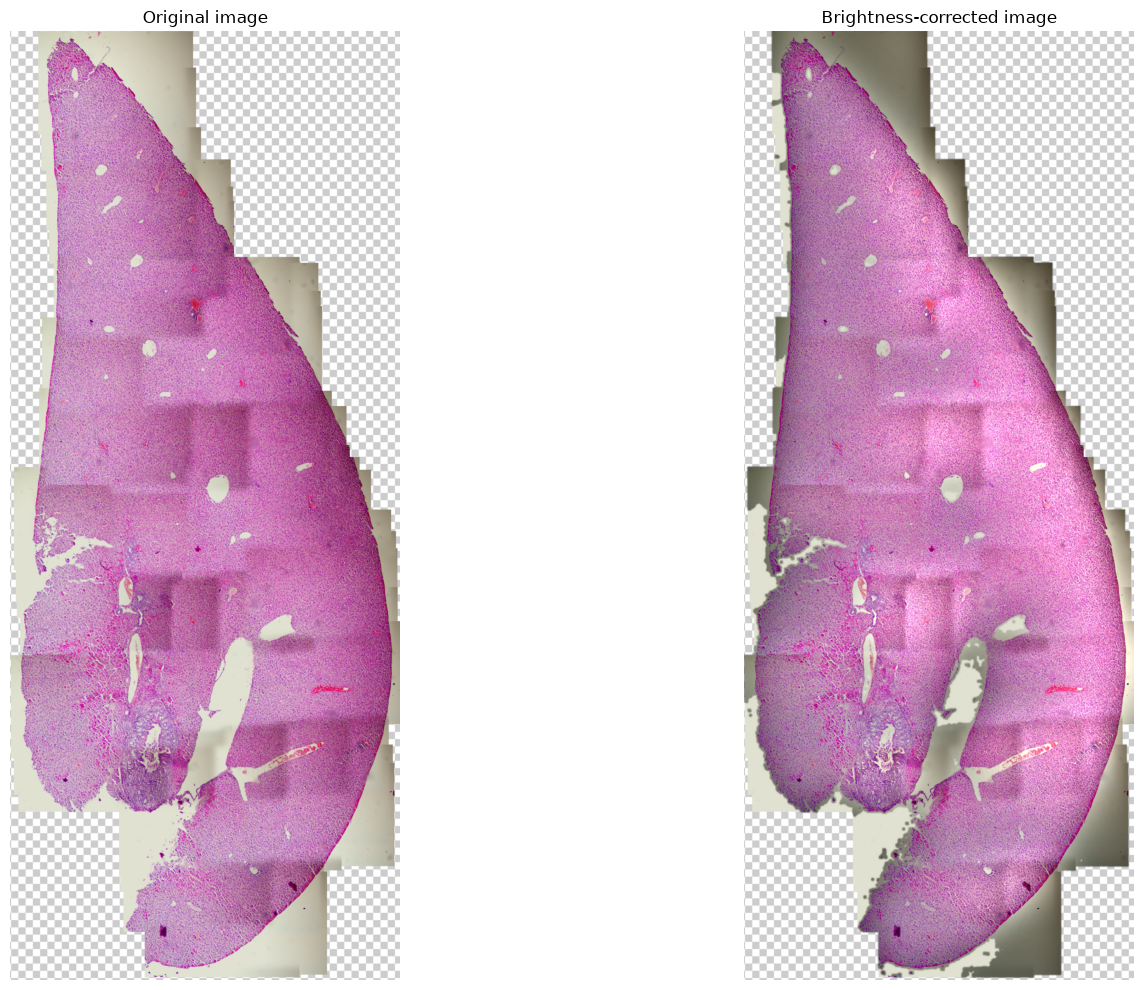

In [392]:
show_bgr_pair(
    bgr,
    corrected_bgr,
    original_title="Original image",
    corrected_title="Brightness-corrected image"
)

In [344]:
# --------------------------------------------------
# Save with Pillow
# --------------------------------------------------
corrected_pil = Image.fromarray(corrected_rgb)
corrected_pil.save(output_path)

print("Correction completed.")
print("Saved to:", output_path)

Correction completed.
Saved to: c:\Users\Yarik\OneDrive\Рабочий стол\python_modules\Four_host_species_OF\full_view\Balbc_10x_2k_corrected.png
